# Notebook to fit mocks:

**Remark:** 
 * I work in my local branch of `desi-clustering`: `edmond-dev`
 * For now it turns with `desilike/dr2-dev`

In [2]:
import logging

import os
from pathlib import Path
from matplotlib.backends.backend_pdf import PdfPages
import functools

import numpy as np
import matplotlib.pyplot as plt

logger = logging.getLogger('FIT PNG')

plt.style.use('ec_style.mplstyle')   

# remove warning on my mac -> deactivate on NERSC.
os.environ['OMPI_MCA_btl'] = 'self,tcp'  # deactivate shmem
# disable jax warning:
logging.getLogger("jax._src.xla_bridge").setLevel(logging.ERROR)
logging.getLogger("jax._src.distributed").setLevel(logging.ERROR)
# Remove warning from jax
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

In [3]:
import itertools
import tqdm
from concurrent.futures import ProcessPoolExecutor

import lsstypes
from clustering_statistics.tools import get_stats_fn

from tools import run_profiling_one_mock

import os
import re
from pathlib import Path
from collections import defaultdict

from tools import get_getdist_plotter, plot_triangle

In [4]:
def propose_fiducial(kmin=1e-3, kmax=8e-2, region='GCcomb'):
    """ 
    """
    propose_fiducial = {}

    propose_fiducial['LRG'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.4, 1.1), 'region': region, 
                               'use_ell2': True, 'kmin': kmin, 'kmax': kmax, 'kmin_ell2': kmin, 'kmax_ell2': kmax}
    propose_fiducial['ELG'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.8, 1.6), 'region': region, 
                               'use_ell2': True, 'kmin': kmin, 'kmax': kmax, 'kmin_ell2': kmin, 'kmax_ell2': kmax} 
    propose_fiducial['QSO'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.8, 3.5), 'region': region, 
                               'use_ell2': True, 'kmin': kmin, 'kmax': kmax, 'kmin_ell2': kmin, 'kmax_ell2': kmax}   
      
    propose_fiducial['LRGxQSO'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.8, 1.1), 'region': region, 
                                   'use_ell2': True, 'kmin': kmin, 'kmax': kmax, 'kmin_ell2': kmin, 'kmax_ell2': kmax}   
    propose_fiducial['LRGxELG'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.8, 1.1), 'region': region, 
                                   'use_ell2': True, 'kmin': kmin, 'kmax': kmax, 'kmin_ell2': kmin, 'kmax_ell2': kmax   }   
    propose_fiducial['ELGxQSO'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.8, 1.6), 'region': region, 
                                   'use_ell2': True, 'kmin': kmin, 'kmax': kmax, 'kmin_ell2': kmin, 'kmax_ell2': kmax}   
    
    # when sort tracer name, ELG arrive first, so it is convienient to have it here as well 
    propose_fiducial['ELGxLRG'] = propose_fiducial['LRGxELG']

    return propose_fiducial



def load_data(data_dir, mocks_dir, tracer, fiducial=propose_fiducial(), window_extra='RIC+AMR', nmocks_mean=None, 
              kpivot=[1e-2, 2e-2], nrebin=[2,2], weight_type_mocks=None, nmocks=None):
    """ 
    """
    import lsstypes 

    from tools import read_data, rebin_data

    short_tracer = tracer.replace('_zcmb', '')
    short_tracer = short_tracer.replace('notqso', '')

    if weight_type_mocks is None: weight_type_mocks = 'default-noimsys-fkp-oqe_reshuffle' if window_extra == '' else 'default-fkp-oqe'
    logger.info(f"Reading data for tracer {tracer} with weight type {weight_type_mocks} and window_extra={window_extra}.")

    kwargs = fiducial[short_tracer]
    if nmocks is not None:
        kwargs['nmocks'] = nmocks

    pk, window, cov, mock = read_data(data_dir=data_dir, mocks_dir=mocks_dir, tracer=tracer, window_extra=window_extra,
                                        weight_type_mocks=weight_type_mocks, **kwargs)
    pk, window, cov, mock = rebin_data(pk, window, cov, mock, tracer=tracer, kpivot=kpivot, nrebin=nrebin, **kwargs)
    try: 
        logger.info(f'After rebinning and k range selection: {pk.get(0).k.shape[0]} and {pk.get(2).k.shape[0]} data points.')
    except KeyError:
        logger.info(f'After rebinning and k range selection: {pk.get(0).k.shape[0]} data points.')

    if nmocks_mean is not None:
        # Keep only mocks that are not used in the mean, to have independent mocks for covariance validation and likelihood profiling.
        mean_mock = lsstypes.mean(mock[:nmocks_mean])
        mock = mock[nmocks_mean:]

    zeff = {}
    zeff[0] = window.observable.get(0).attrs['zeff']
    try: 
        zeff[2] = window.observable.get(2).attrs['zeff']
    except KeyError:
        pass

    if nmocks_mean is not None:
        return pk, window, cov, zeff, mock, mean_mock
    else:
        return pk, window, cov, zeff, mock

## Load data: 

In [6]:
# root = '/global/cfs/cdirs/desi/science/cai/desi-clustering/'
root = '/Users/edmond/Work/data/desi-clustering/' 

# Where the data are:
data_dir =  root + 'dr2/summary_statistics/local_png/base/desi-data/loa-v1/v2/fNL/blinded'
# Where the mocks are:
mocks_dir = root + 'dr2/summary_statistics/local_png/base/'

tracer_to_load = ['LRG', 'QSO', 'LRGxQSO', 'ELGnotqso', 'LRGxELGnotqso', 'ELGnotqsoxQSO'][:]

regions = ['GCcomb', 'NGC', 'SGC']
kmin = 1e-3

nmean = 50  # number of mocks to use for the mean. 

pk, zeff = {}, {}
window, mocks, mean_mocks = {}, {}, {}

std = {}

for tracer in tracer_to_load:

    tracer_to_read = tracer
    tracer = 'x'.join([tracer[:3], tracer[:3]]) if 'x' not in tracer else tracer.replace('notqso', '')

    pk[tracer], window[tracer], mocks[tracer], mean_mocks[tracer], zeff[tracer], std[tracer] = {}, {}, {}, {}, {}, {}
    for region in regions:
        fiducial = propose_fiducial(kmin=kmin, region=region)

        window[tracer][region], mocks[tracer][region], mean_mocks[tracer][region] = {}, {}, {}

        pk[tracer][region], window[tracer][region]['RIC+AMR'], _, zeff[tracer][region], mocks[tracer][region]['RIC+AMR'] = load_data(data_dir, mocks_dir, tracer_to_read, fiducial, window_extra='RIC+AMR')
        # for plotting purpose:
        std[tracer][region] = np.sqrt(np.diag(lsstypes.cov(mocks[tracer][region]['RIC+AMR']).value()))

        for key in ['', 'RIC', 'DR1-RIC', 'DR1-RIC+AMR']:
            if key == '':
                weight_type_mocks = 'default-noimsys-fkp-oqe_reshuffle'
            elif key in ['RIC', 'DR1-RIC']:
                weight_type_mocks = 'default-noimsys-fkp-oqe'
            else:
                weight_type_mocks = 'default-fkp-oqe'

            try:
                _, window[tracer][region][key], _, _, mocks[tracer][region][key] = load_data(data_dir, mocks_dir, tracer_to_read, fiducial, window_extra=key,
                                                                weight_type_mocks=weight_type_mocks, nmocks=nmean)
            except FileNotFoundError:
                window[tracer][region][key], mocks[tracer][region][key] = None, None

        for key in ['', 'RIC', 'DR1-RIC', 'RIC+AMR', 'DR1-RIC+AMR']:
            mean_mocks[tracer][region][key] = lsstypes.mean(mocks[tracer][region][key][:nmean]) if mocks[tracer][region][key] is not None else None

        if 'ELG' in tracer:
            weight_type_mocks = {
                'ELGnotqso': 'default-fkp-oqe-wsys-imlin',
                'LRGxELGnotqso': 'default-fkp-oqexdefault-fkp-oqe-wsys-imlin',
                'ELGnotqsoxQSO': 'default-fkp-oqe-wsys-imlinxdefault-fkp-oqe',
            }[tracer_to_read]

            if key in ['RIC+AMR', 'DR1-RIC+AMR']:  # only load mocks for this weight type, to save time and disk space.
                tmp = load_data(data_dir, mocks_dir, tracer_to_read, fiducial, window_extra='RIC+AMR', weight_type_mocks=weight_type_mocks, nmocks=nmean)[-1]
                mean_mocks[tracer][region]['RIC+AMR'] = lsstypes.mean(tmp)
            else:
                mean_mocks[tracer][region]['RIC+AMR'] = None

        # Load Glam mocks:
        # try:
        #     fns_mock = [get_stats_fn(kind='mesh2_spectrum_poles', stats_dir=mocks_dir, project='glam-uchuu-v2-altmtl', tracer=tracer, region=region, 
        #                              weight='default-fkp-oqe', imock=imock) for imock in range(150, 250) if imock not in [210,243]] 
        #     glams[tracer][region] = [lsstypes.read(fn).match(pk[tracer][region]) for fn in fns_mock]
        #     mean_glams[tracer][region] = lsstypes.mean(glams[tracer][region][:nmean])
        # except KeyError:
        #     glams[tracer][region], mean_glams[tracer][region] = None, None

zeffs = {}
for reg in regions:
    zeffs[reg] = {}
    for tracer in tracer_to_load:
        # for likelihood building:
        tracer = 'x'.join([tracer[:3], tracer[:3]]) if 'x' not in tracer else tracer.replace('notqso', '')
        zeffs[reg][tracer] = zeff[tracer][reg]

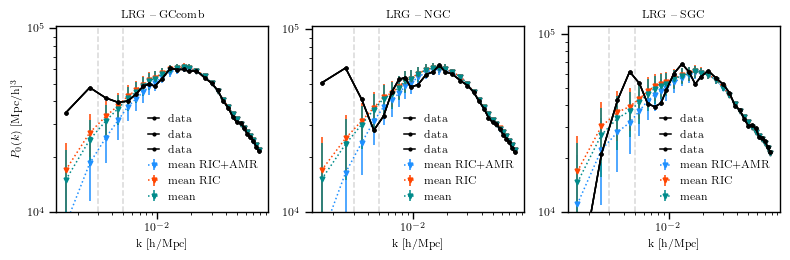

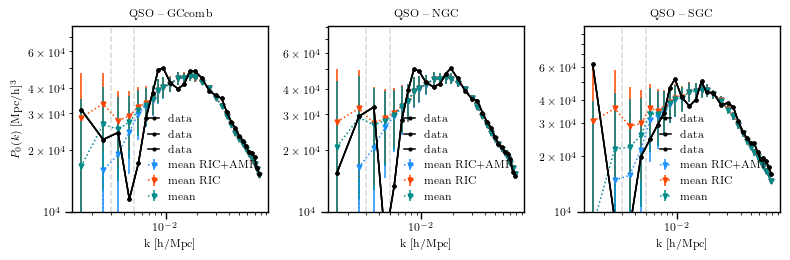

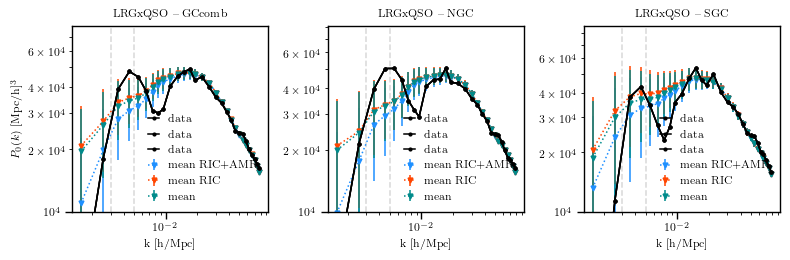

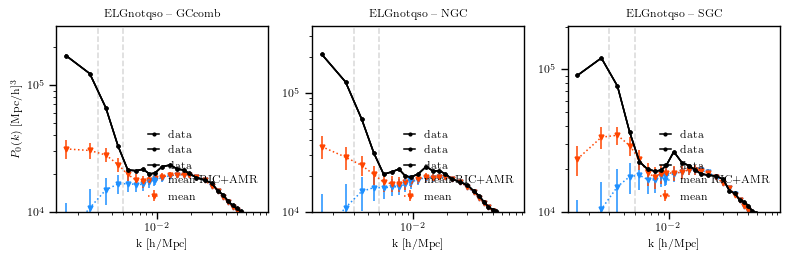

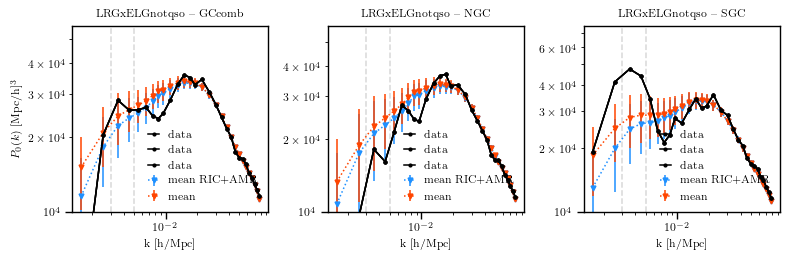

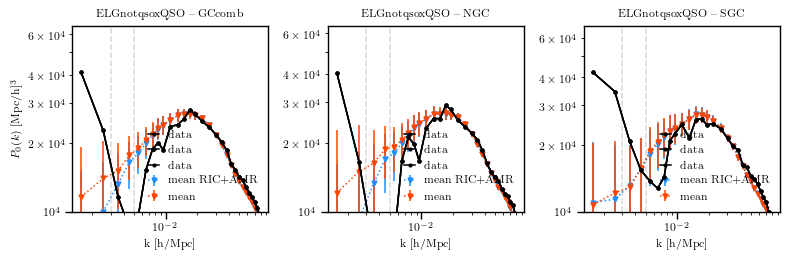

In [7]:
for tracer in tracer_to_load:

    tracer_save = tracer
    tracer = 'x'.join([tracer[:3], tracer[:3]]) if 'x' not in tracer else tracer.replace('notqso', '')

    plt.figure(figsize=(8,2.7))

    for i, reg in enumerate(regions):
        plt.subplot(131+i)
        for key in ['RIC+AMR', 'RIC', '']:
            if mean_mocks[tracer][reg][key] is not None:
                size_for_std = mean_mocks[tracer][reg][key].get(0).k.size
                plt.errorbar(mean_mocks[tracer][reg][key].get(0).k, mean_mocks[tracer][reg][key].get(0).value(), yerr=std[tracer][reg][:size_for_std], label=f'mean {key}', marker='v', markersize=3.5, ls=':')

            #if mean_glams[tracer][reg] is not None:
            #    plt.plot(mean_glams[tracer][reg].get(0).k, mean_glams[tracer][reg].get(0).value(), label='mean glams', marker='x', ls='--', zorder=1)

            plt.loglog(pk[tracer][reg].get(0).k, pk[tracer][reg].get(0).value(), label='data', marker='.', c='k', zorder=20)

        plt.axvline(3e-3, ls='--', c='gray', alpha=0.3)
        plt.axvline(5e-3, ls='--', c='gray', alpha=0.3)

        plt.xlabel('k [h/Mpc]')
        if i == 0: plt.ylabel(r'$P_0(k)$ [Mpc/h]$^3$')
        plt.title(f'{tracer_save} -- {reg}')
        plt.ylim(1e4, None)
        plt.legend(loc='lower right')

    plt.tight_layout()
    plt.savefig(f'fig/mean_mocks_{tracer_save}.png', dpi=400)
    plt.show()

In [9]:
def create_theory(b1=2.0, zeff=0.733, shotnoise=0.0):
    from lsstypes import Mesh2SpectrumPole, Mesh2SpectrumPoles
    from cosmoprimo.fiducial import DESI

    cosmo = DESI(engine='eisenstein_hu')

    f = cosmo.growth_rate(zeff)

    edges = np.linspace(0., 0.3, 1001)
    edges = np.column_stack([edges[:-1], edges[1:]])
    kk = np.mean(edges, axis=-1)

    pk = cosmo.get_fourier().pk_interpolator(of='delta_cb')(kk, z=zeff)
    f = cosmo.growth_rate(zeff)
    shotnoise = np.ones_like(kk) * shotnoise

    ells = (0, 2, 4)
    poles = []
    poles.append((b1**2 + 2. / 3. * f * b1 + 1. / 5. * f**2) * pk + shotnoise)
    poles.append((4. / 3. * f * b1 + 4. / 7. * f**2) * pk)
    poles.append(8. / 35 * f**2 * pk)
    poles = np.array(poles, dtype='f8')

    theo = [Mesh2SpectrumPole(k=kk, k_edges=edges, num_raw=value, num_shotnoise=(ell == 0) * shotnoise, ell=ell) for ell, value in zip(ells, poles)]
    theo = Mesh2SpectrumPoles(theo)

    return theo

def convolve_theory(theo, window, add_shotnoise=False):
    # Rebin the theory to match the input window.
    theo = theo.match(window.theory)

    # value() is read-only; use clone(value=...) to create an updated copy.
    if add_shotnoise:
        values = [theo.get(ell).value().copy() for ell in theo.ells]
        for iell, ell in enumerate(theo.ells):
            if ell == 0:
                values[iell] += theo.get(ell).num_shotnoise / theo.get(ell).norm
                break
        theo = theo.clone(value=np.concatenate(values))

    # Convolve the rebinned theory with the window.
    return window.dot(theo, return_type=None)

In [10]:
if False:
    shotnoise =  (pk.get(0).num_shotnoise / pk.get(0).norm)[0]
    theo = create_theory(b1=2.1, zeff=0.818, shotnoise=shotnoise)
    conv = convolve_theory(theo, window[''])
    conv_w_sn = convolve_theory(theo, window[''], add_shotnoise=True)

    plt.figure(figsize=(6,2.7))
    plt.subplot(131)
    plt.loglog(theo.get(0).k, theo.get(0).value(), label='theory')
    sn = np.ones_like(theo.get(0).k) * theo.get(0).num_shotnoise / theo.get(0).norm
    plt.loglog(theo.get(0).k, sn, c='gray', ls='--', label='shotnoise')
    plt.loglog(theo.get(0).k, theo.get(0).value() + sn, label='theory w. sn')
    sn_data = np.ones_like(pk.get(0).k) * pk.get(0).num_shotnoise / pk.get(0).norm
    plt.loglog(pk.get(0).k, pk.get(0).value() + sn_data, ls='--', c='k', label='data w. sn')
    plt.legend()
    plt.xlabel(r'$k$ [$h/$Mpc]')
    plt.ylabel(r'$P_{0}(k)$ [$(\rm{Mpc}/h)^3$]')
    plt.subplot(132)
    plt.plot(conv_w_sn.get(0).k, (conv.get(0).value() - (conv_w_sn.get(0).value() -  shotnoise)))
    plt.xscale('log')
    plt.axhline(-200, ls='--', c='gray')
    plt.legend()
    plt.xlabel(r'$k$ [$h/$Mpc]')
    plt.ylabel(r'ratio')
    plt.subplot(133)
    plt.plot(conv_w_sn.get(0).k, (conv.get(0).value()), label='conv wo shotnoise')
    plt.loglog(conv_w_sn.get(0).k, (conv_w_sn.get(0).value() -  shotnoise), label='conv with shotnoise')
    plt.legend()
    plt.xlabel(r'$k$ [$h/$Mpc]')
    plt.ylabel(r'P_0(k) [$(\rm{Mpc}/h)^3$]')
    plt.tight_layout()
    plt.show()

/Users/edmond/Developer/Software/cosmoprimo/cosmoprimo/eisenstein_hu.py:25: UserWarning: EisensteinHuEngine cannot cope with massive neutrinos
  warnings.warn('{} cannot cope with massive neutrinos'.format(self.__class__.__name__))


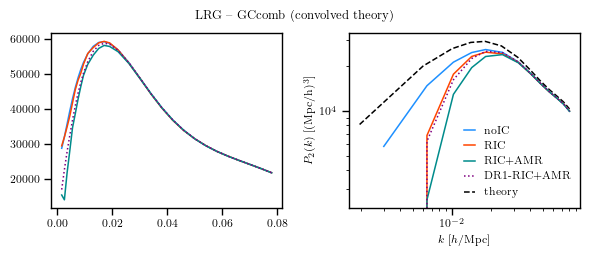

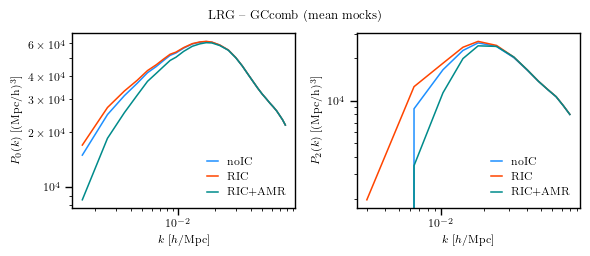

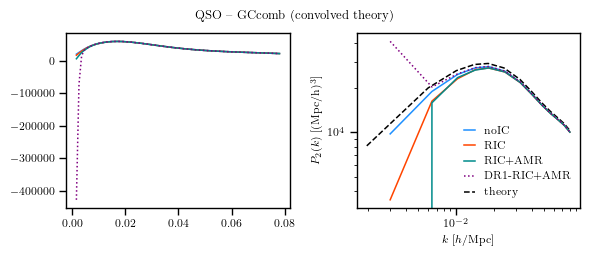

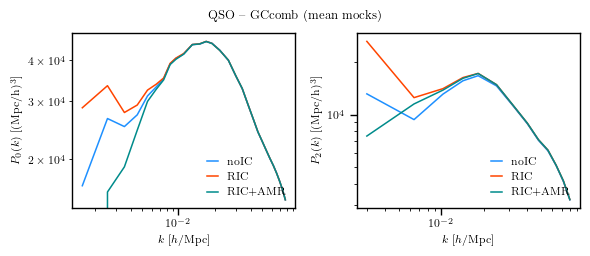

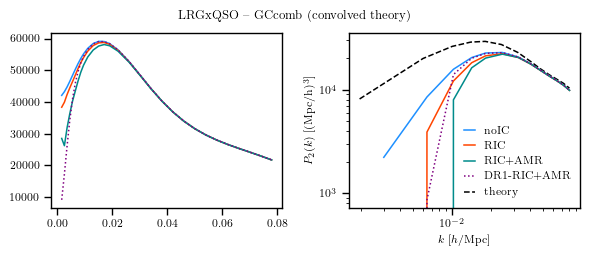

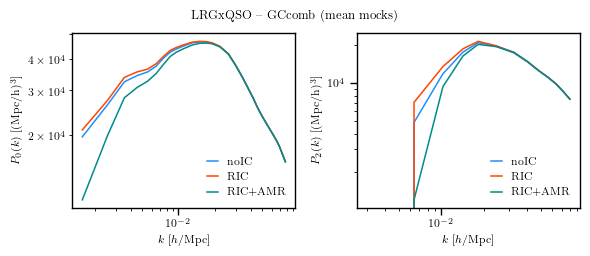

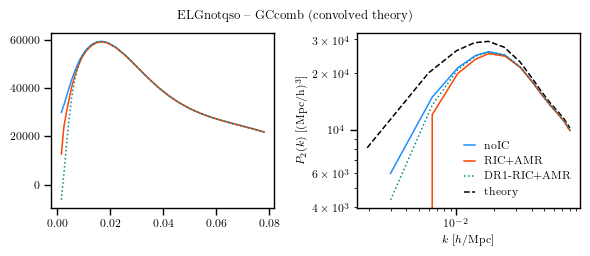

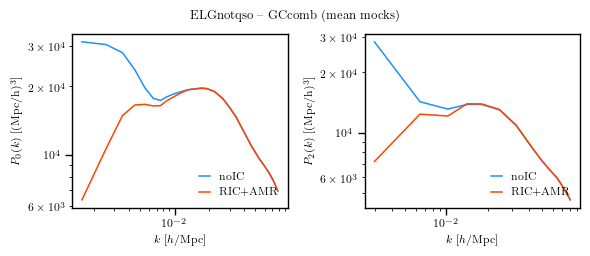

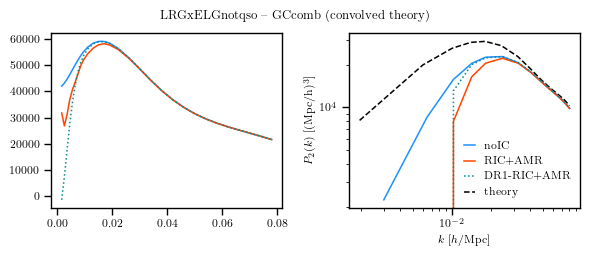

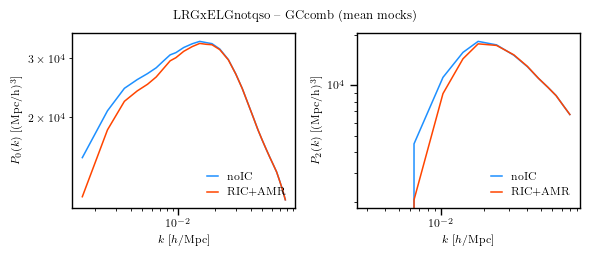

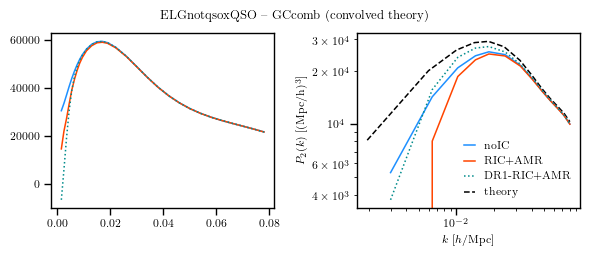

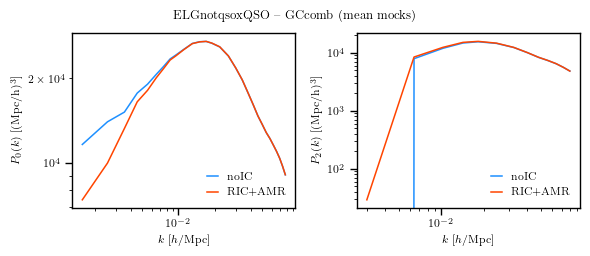

In [11]:
for tracer in tracer_to_load:

    tracer_save = tracer
    tracer = 'x'.join([tracer[:3], tracer[:3]]) if 'x' not in tracer else tracer.replace('notqso', '')

    reg = 'GCcomb'

    shotnoise =  (pk[tracer][reg].get(0).num_shotnoise / pk[tracer][reg].get(0).norm)[0]
    theo = create_theory(b1=2.1, zeff=0.818, shotnoise=shotnoise)

    plt.figure(figsize=(6,2.7))

    for i, ell in enumerate([0, 2]):
        plt.subplot(121+i)

        for key in ['', 'RIC', 'RIC+AMR', 'DR1-RIC+AMR']:
            try:
                conv_theo = convolve_theory(theo, window[tracer][reg][key])
                label = 'noIC' if key == '' else key  #it has GIC but not RIC/AMR.
                ls = ':' if 'DR1' in key else '-'
                plt.plot(conv_theo.get(ell).k, conv_theo.get(ell).value(), ls=ls, label=label)
            except AttributeError:
                continue

    tmp = theo.match(conv_theo)
    plt.loglog(tmp.get(ell).k, tmp.get(ell).value(), label='theory', c='k', ls='--', zorder=0)

    plt.xlabel(r'$k$ [$h/$Mpc]')
    plt.ylabel(rf'$P_{ell}(k)$' + r' [$(\rm{Mpc}/h)^3$]')
    plt.legend(loc='lower right')

    plt.suptitle(f'{tracer_save} -- {reg} (convolved theory)', y=0.93, fontsize=9)
    plt.tight_layout()
    plt.show()

        
    plt.figure(figsize=(6,2.7))

    for i, ell in enumerate([0, 2]):
        plt.subplot(121+i)

        for key in ['', 'RIC', 'RIC+AMR']:
            try:
                to_plot = mean_mocks[tracer][reg][key]
                label = 'noIC' if key == '' else key  #it has GIC but not RIC/AMR.
                ls = ':' if 'DR1' in key else '-'
                plt.loglog(to_plot.get(ell).k, to_plot.get(ell).value(), ls='-', label=label)
            except AttributeError:
                continue
        plt.xlabel(r'$k$ [$h/$Mpc]')
        plt.ylabel(rf'$P_{ell}(k)$' + r' [$(\rm{Mpc}/h)^3$]')
        plt.legend(loc='lower right')

    plt.suptitle(f'{tracer_save} -- {reg} (mean mocks)', y=0.93, fontsize=9)
    plt.tight_layout()
    plt.show()


## Let's fit the mean of the mocks...

In [12]:
from tools import get_observable_and_likelihood, run_profiler, run_mcmc, plot_observables

profilers = {}
chains = {}

dir_chains = '/Users/edmond/Work/data/desi-clustering/dr2/chains/local_png/base/holi-v3-altmtl/mean_mocks'
force_mcmc = False  # set to True to re-run MCMC even if chains already exist (use with caution as it can be time-consuming)

for tracer in tracer_to_load:

    tracer_save = tracer
    tracer = 'x'.join([tracer[:3], tracer[:3]]) if 'x' not in tracer else tracer.replace('notqso', '')

    if tracer == 'QSOxQSO':
        kmin_prof = [1e-3, 3e-3, 5e-3, 7e-3]
        kmin_chains = [1e-3, 3e-3, 5e-3] 
    elif tracer == 'ELGxELG':
        kmin_prof = [8e-3, 1e-2]
        kmin_chains = [8e-3, 1e-2]
    else:
        kmin_prof = [1e-3, 3e-3, 5e-3, 7e-3]
        kmin_chains = [3e-3, 5e-3]

    for key in tqdm.tqdm(['', 'RIC', 'RIC+AMR']):  # 'DR1-RIC', 'DR1-RIC+AMR'
        for region in regions:
            for kmin in kmin_prof:
                try:
                    # Restrict mocks to k>kmin:
                    pp = mean_mocks[tracer][region][key].select(k=(kmin, 1))
                    ww = window[tracer][region][key].at.observable.match(pp)
                    mm = [mock.select(k=(kmin, 1)) for mock in mocks[tracer][region]['RIC+AMR']]   # use 1000 EZmocks

                    obs, lik = get_observable_and_likelihood(pp, ww, mm, tracer, zeffs[region], engine='camb', fix_fnl=False, nickname=tracer) 
                    profilers[(tracer, region, key, kmin)] = run_profiler(lik)
                    
                    # running chains can be long ... 
                    if key in ['', 'RIC', 'RIC+AMR'] and kmin in kmin_chains:  # only run MCMC for a subset of cases to save time.
                        key_tag = 'noIC' if key == '' else key
                        fn_chain = f"{dir_chains}/chains_{tracer_save}_nmean_{nmean}_{region}_{key_tag}_kmin-{kmin:.0e}_*.npy"
                        if not Path(fn_chain.replace('*', '0')).exists() or force_mcmc:  # avoid re-running if chain already exists
                            chains[(tracer, region, key, kmin)] = run_mcmc(lik, fn_output=fn_chain, max_iterations=20000, check_every=10000).chains
                        else:
                            from desilike.samples import Chain
                            import glob
                            chains[(tracer, region, key, kmin)] = [Chain.load(fn) for fn in sorted(glob.glob(fn_chain))]
                            Chain.load(fn_chain.replace('*', '0'))

                    #if kmin == 1e-3:
                    #    print(profilers[(tracer, region, key, kmin)].profiles.to_stats(tablefmt="pretty"))
                    #    plot_observables({tracer: obs}, figsize=(4,3))

                    #plot_observables({tt: obs[tt] for tt in order})

                except AttributeError:
                    continue


    # for region in regions:
    #     print('GLAM ({region}): ')
    #     obs, lik = get_observable_and_likelihood(mean_glams[tracer][region], window[tracer][region]['RIC+AMR'], mocks[tracer][region]['RIC+AMR'], tracer, zeffs[region][tracer], 
    #                                             engine='camb', fix_fnl=False, nickname=tracer)
    #     profiler = run_profiler(lik)
    #     print(profiler.profiles.to_stats(tablefmt="pretty"))
    #     plot_observables({tracer: obs}, figsize=(4,3))

100%|██████████| 3/3 [01:23<00:00, 27.96s/it]


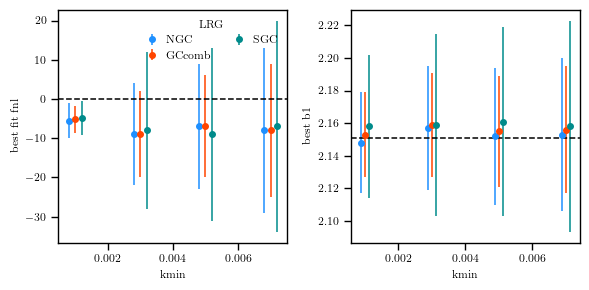

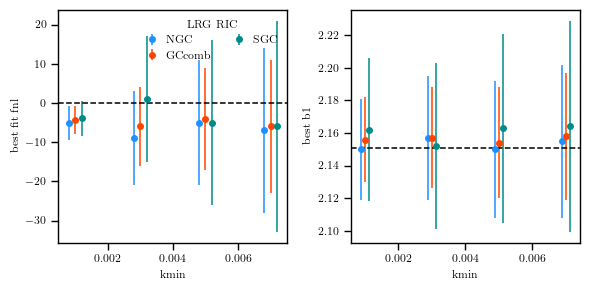

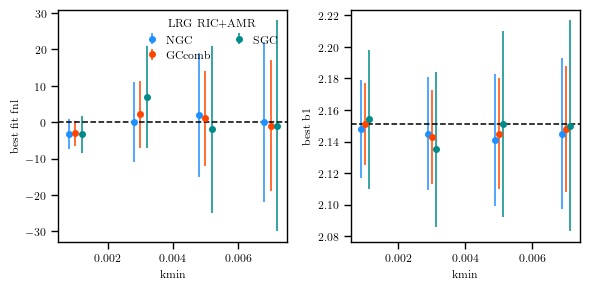

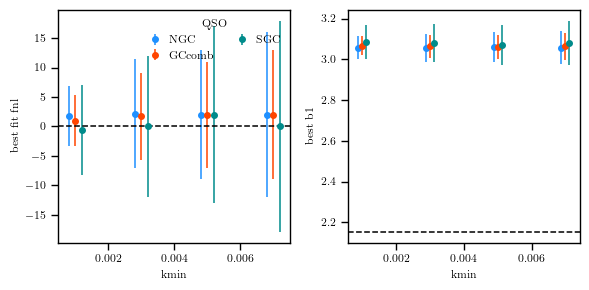

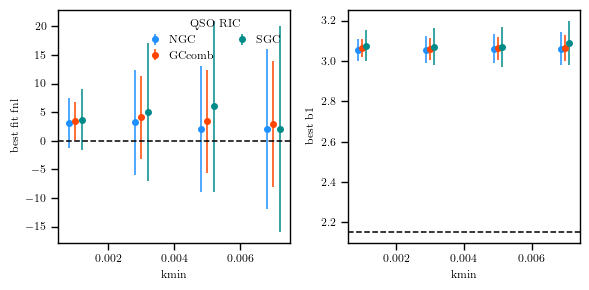

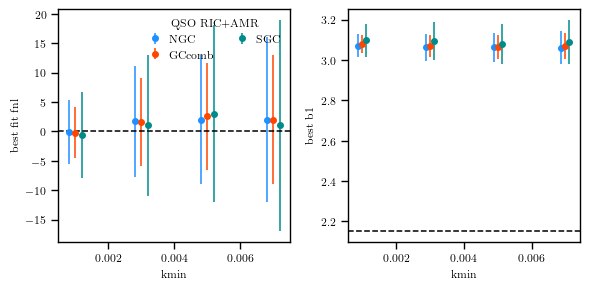

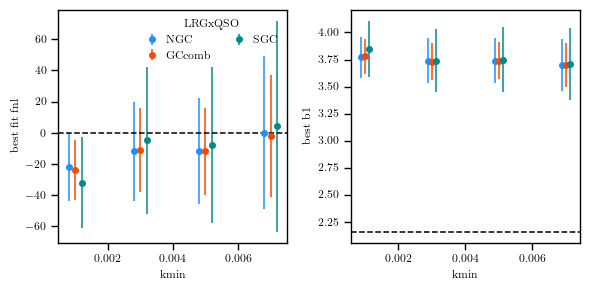

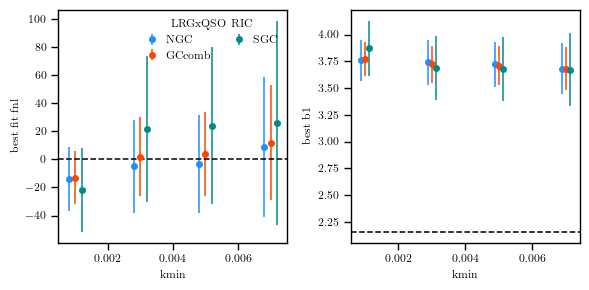

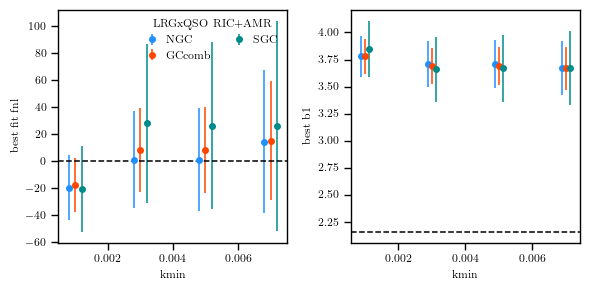

<Figure size 600x300 with 0 Axes>

<Figure size 600x300 with 0 Axes>

<Figure size 600x300 with 0 Axes>

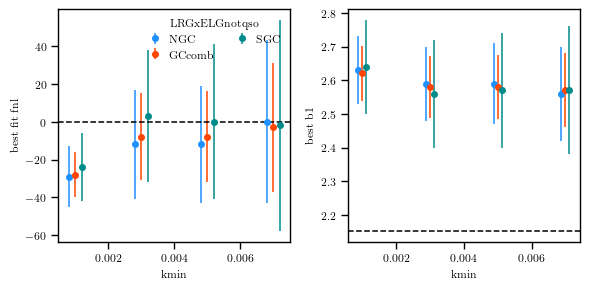

<Figure size 600x300 with 0 Axes>

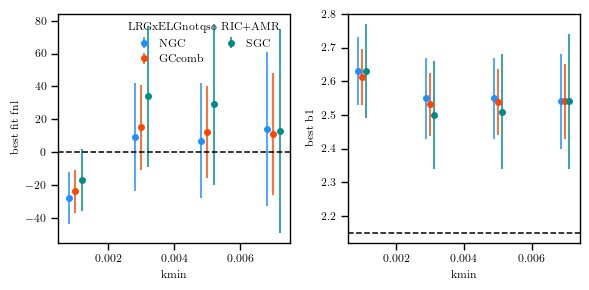

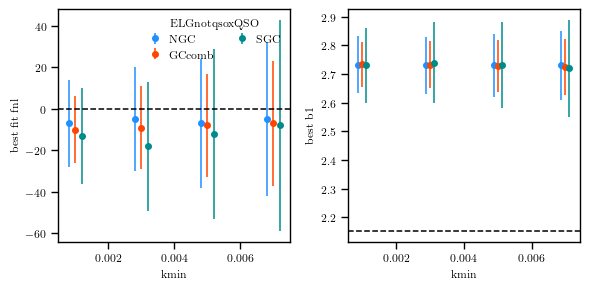

<Figure size 600x300 with 0 Axes>

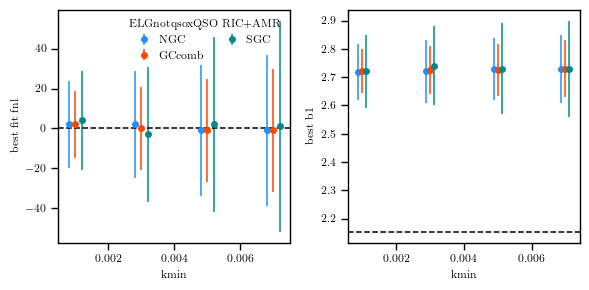

In [13]:
for tracer in tracer_to_load:

    tracer_save = tracer
    tracer = 'x'.join([tracer[:3], tracer[:3]]) if 'x' not in tracer else tracer.replace('notqso', '')

    for key in ['', 'RIC', 'RIC+AMR']:
        try:
            plt.figure(figsize=(6,3))
            for i, region in enumerate(['NGC', 'GCcomb', 'SGC']):
                fnl, b1 = [], []
                for kmin in kmin_prof:
                    profiler = profilers[(tracer, region, key, kmin)]

                    fnl.append([kmin, float(profiler.profiles.to_stats(tablefmt="list")[0][0][-2]), float(profiler.profiles.to_stats(tablefmt="list")[0][0][-1])])
                    b1.append([kmin, float(profiler.profiles.to_stats(tablefmt="list")[0][2][-2]), float(profiler.profiles.to_stats(tablefmt="list")[0][2][-1])])
                    
                plt.subplot(121)
                plt.errorbar([t[0] + (i-1)*0.0002 for t in fnl], [t[1] for t in fnl], yerr=[t[2] for t in fnl], marker='o', ls='', label=region)
                plt.subplot(122)
                plt.errorbar([t[0] + (i-1)*0.00012 for t in b1], [t[1] for t in b1], yerr=[t[2] for t in b1], marker='o', ls='')

            plt.subplot(121)
            plt.axhline(0, ls='--', c='k')
            plt.legend(title=tracer_save + ' ' + key, ncol=2)
            plt.xlabel('kmin')
            plt.ylabel('best fit fnl')
            plt.subplot(122)
            plt.axhline(2.151, ls='--', c='k')
            plt.xlabel('kmin')
            plt.ylabel('best b1')
            plt.tight_layout()
            plt.savefig(f'fig/{tracer_save}_{key}_fit_kmin.png', dpi=400)
            plt.show()
        
        except KeyError:
            continue

/var/folders/vh/lq2m97v91l34jy4xn7vjsr5h0000gn/T/ipykernel_19564/2101599789.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(f'fig/{tracer_save}_mocks_mcmc_test{key}_{ii}.png', dpi=400)
/opt/homebrew/Caskroom/miniconda/base/envs/cosmo3.12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


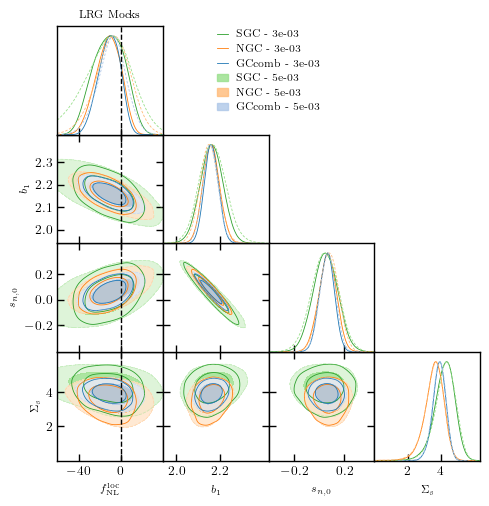

/var/folders/vh/lq2m97v91l34jy4xn7vjsr5h0000gn/T/ipykernel_19564/2101599789.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(f'fig/{tracer_save}_mocks_mcmc_test{key}_{ii}.png', dpi=400)
/opt/homebrew/Caskroom/miniconda/base/envs/cosmo3.12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


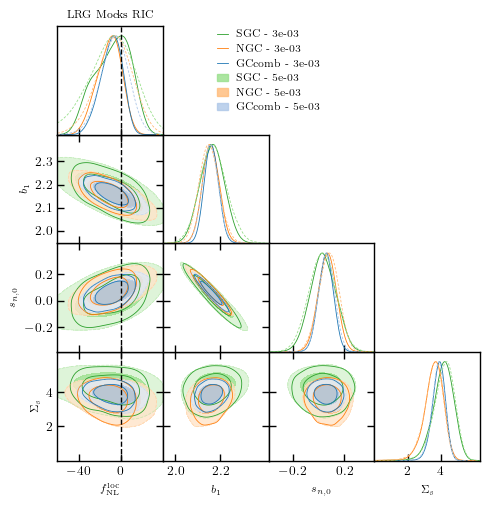

/var/folders/vh/lq2m97v91l34jy4xn7vjsr5h0000gn/T/ipykernel_19564/2101599789.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(f'fig/{tracer_save}_mocks_mcmc_test{key}_{ii}.png', dpi=400)
/opt/homebrew/Caskroom/miniconda/base/envs/cosmo3.12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


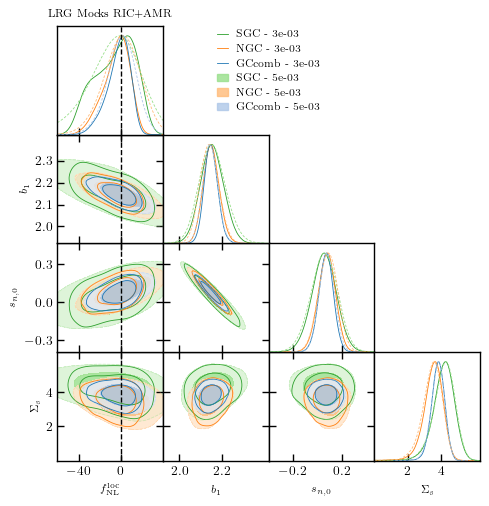

/var/folders/vh/lq2m97v91l34jy4xn7vjsr5h0000gn/T/ipykernel_19564/2101599789.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(f'fig/{tracer_save}_mocks_mcmc_test{key}_{ii}.png', dpi=400)
/opt/homebrew/Caskroom/miniconda/base/envs/cosmo3.12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


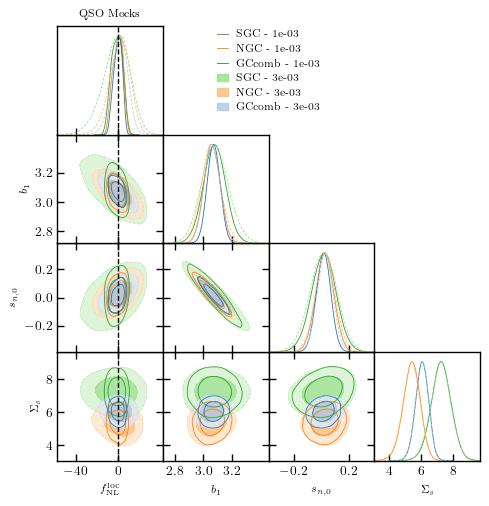

/var/folders/vh/lq2m97v91l34jy4xn7vjsr5h0000gn/T/ipykernel_19564/2101599789.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(f'fig/{tracer_save}_mocks_mcmc_test{key}_{ii}.png', dpi=400)
/opt/homebrew/Caskroom/miniconda/base/envs/cosmo3.12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


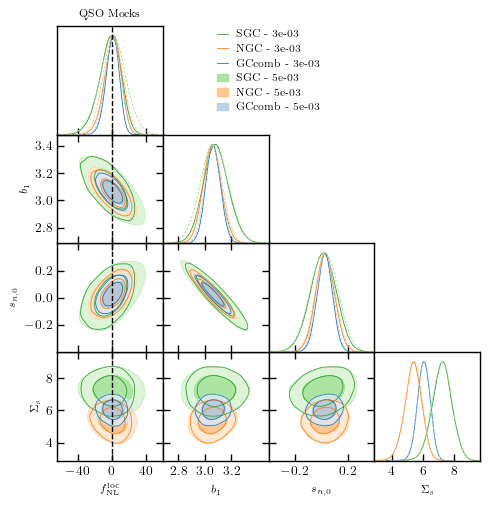

/var/folders/vh/lq2m97v91l34jy4xn7vjsr5h0000gn/T/ipykernel_19564/2101599789.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(f'fig/{tracer_save}_mocks_mcmc_test{key}_{ii}.png', dpi=400)
/opt/homebrew/Caskroom/miniconda/base/envs/cosmo3.12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


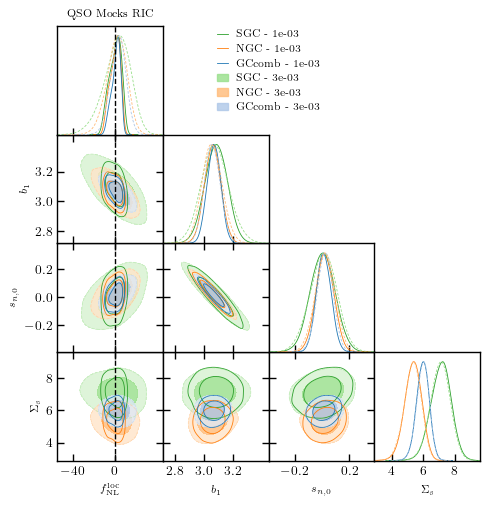

/var/folders/vh/lq2m97v91l34jy4xn7vjsr5h0000gn/T/ipykernel_19564/2101599789.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(f'fig/{tracer_save}_mocks_mcmc_test{key}_{ii}.png', dpi=400)
/opt/homebrew/Caskroom/miniconda/base/envs/cosmo3.12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


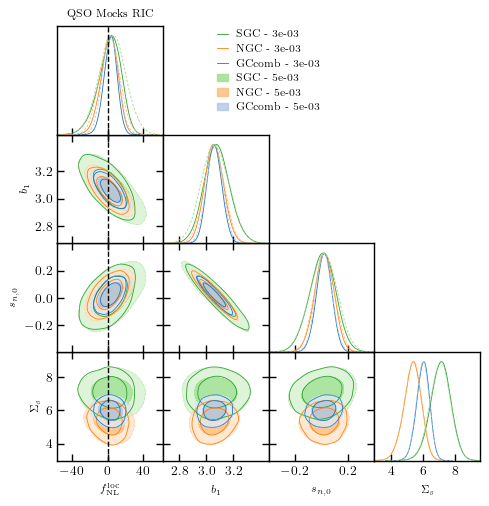

/var/folders/vh/lq2m97v91l34jy4xn7vjsr5h0000gn/T/ipykernel_19564/2101599789.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(f'fig/{tracer_save}_mocks_mcmc_test{key}_{ii}.png', dpi=400)
/opt/homebrew/Caskroom/miniconda/base/envs/cosmo3.12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


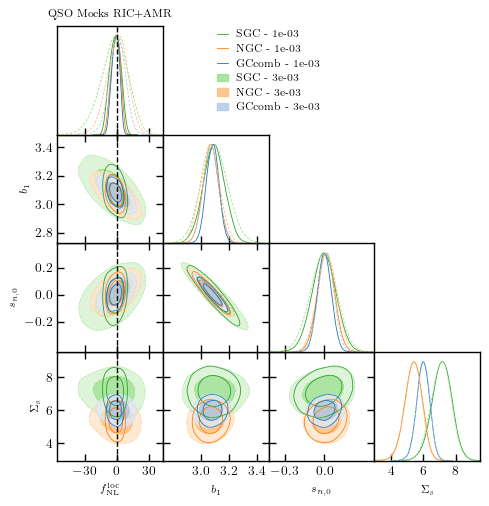

/var/folders/vh/lq2m97v91l34jy4xn7vjsr5h0000gn/T/ipykernel_19564/2101599789.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(f'fig/{tracer_save}_mocks_mcmc_test{key}_{ii}.png', dpi=400)
/opt/homebrew/Caskroom/miniconda/base/envs/cosmo3.12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


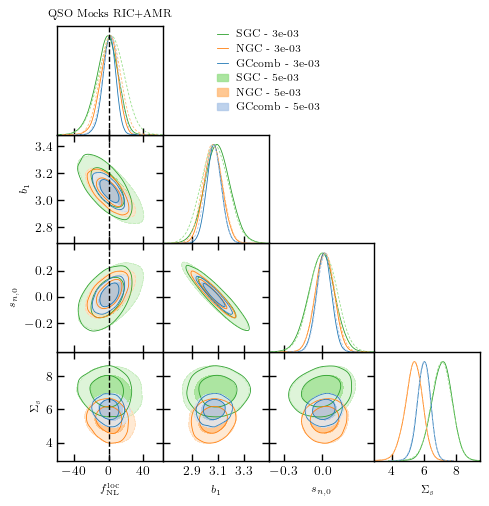

/var/folders/vh/lq2m97v91l34jy4xn7vjsr5h0000gn/T/ipykernel_19564/2101599789.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(f'fig/{tracer_save}_mocks_mcmc_test{key}_{ii}.png', dpi=400)
/opt/homebrew/Caskroom/miniconda/base/envs/cosmo3.12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


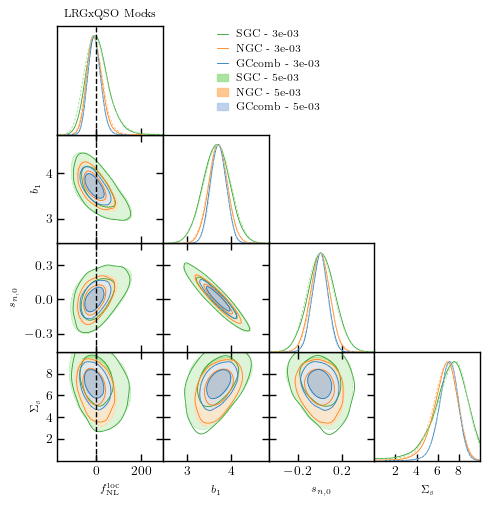

/var/folders/vh/lq2m97v91l34jy4xn7vjsr5h0000gn/T/ipykernel_19564/2101599789.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(f'fig/{tracer_save}_mocks_mcmc_test{key}_{ii}.png', dpi=400)
/opt/homebrew/Caskroom/miniconda/base/envs/cosmo3.12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


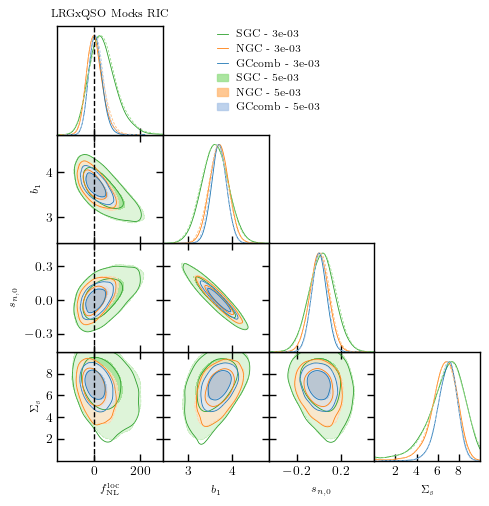

/var/folders/vh/lq2m97v91l34jy4xn7vjsr5h0000gn/T/ipykernel_19564/2101599789.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(f'fig/{tracer_save}_mocks_mcmc_test{key}_{ii}.png', dpi=400)
/opt/homebrew/Caskroom/miniconda/base/envs/cosmo3.12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


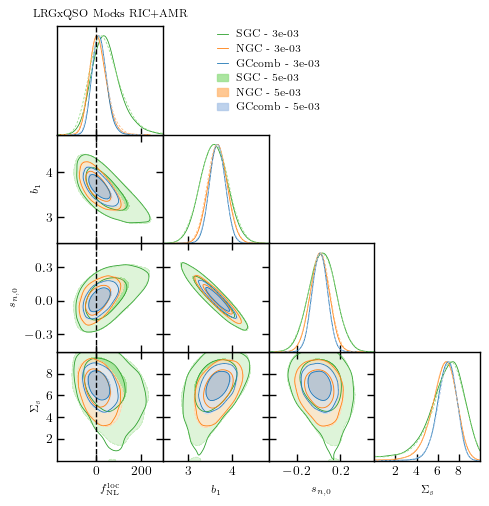

/var/folders/vh/lq2m97v91l34jy4xn7vjsr5h0000gn/T/ipykernel_19564/2101599789.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(f'fig/{tracer_save}_mocks_mcmc_test{key}_{ii}.png', dpi=400)
/opt/homebrew/Caskroom/miniconda/base/envs/cosmo3.12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


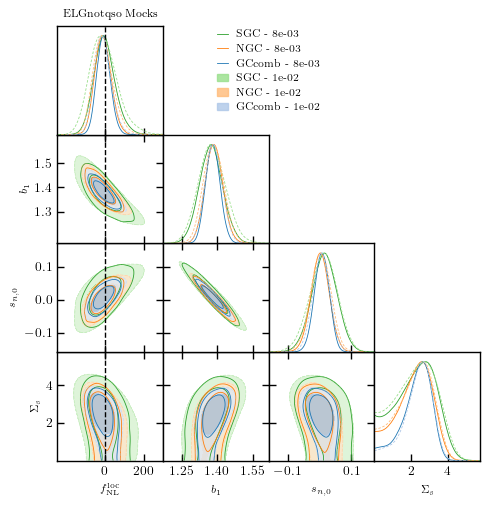

/var/folders/vh/lq2m97v91l34jy4xn7vjsr5h0000gn/T/ipykernel_19564/2101599789.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(f'fig/{tracer_save}_mocks_mcmc_test{key}_{ii}.png', dpi=400)
/opt/homebrew/Caskroom/miniconda/base/envs/cosmo3.12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


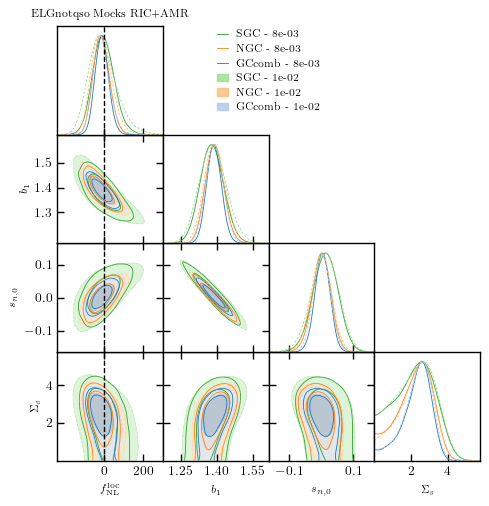

/var/folders/vh/lq2m97v91l34jy4xn7vjsr5h0000gn/T/ipykernel_19564/2101599789.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(f'fig/{tracer_save}_mocks_mcmc_test{key}_{ii}.png', dpi=400)
/opt/homebrew/Caskroom/miniconda/base/envs/cosmo3.12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


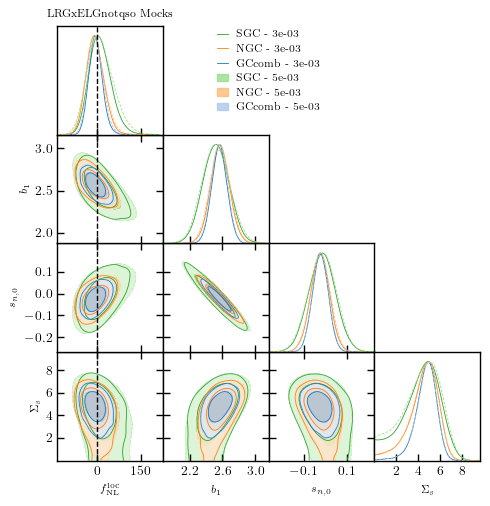

/var/folders/vh/lq2m97v91l34jy4xn7vjsr5h0000gn/T/ipykernel_19564/2101599789.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(f'fig/{tracer_save}_mocks_mcmc_test{key}_{ii}.png', dpi=400)
/opt/homebrew/Caskroom/miniconda/base/envs/cosmo3.12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


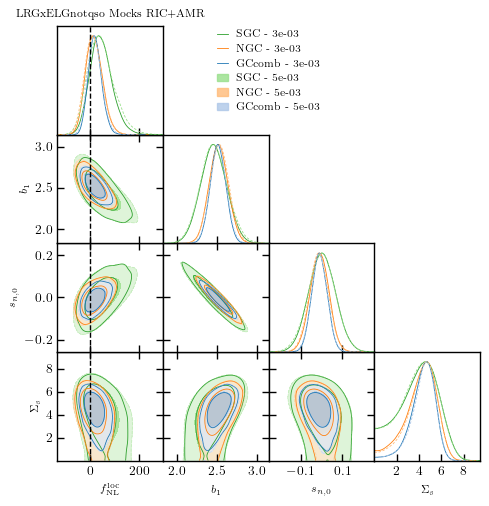

/var/folders/vh/lq2m97v91l34jy4xn7vjsr5h0000gn/T/ipykernel_19564/2101599789.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(f'fig/{tracer_save}_mocks_mcmc_test{key}_{ii}.png', dpi=400)
/opt/homebrew/Caskroom/miniconda/base/envs/cosmo3.12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


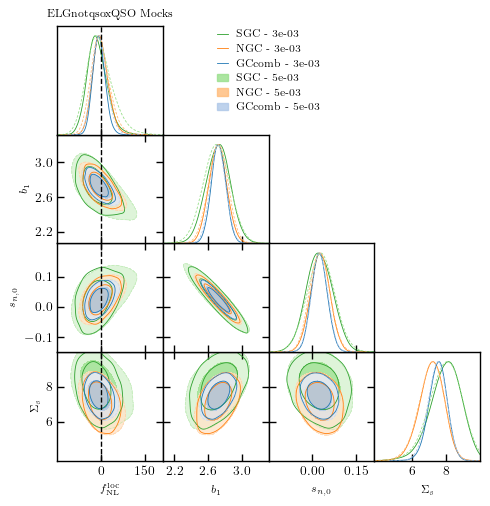

/var/folders/vh/lq2m97v91l34jy4xn7vjsr5h0000gn/T/ipykernel_19564/2101599789.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(f'fig/{tracer_save}_mocks_mcmc_test{key}_{ii}.png', dpi=400)
/opt/homebrew/Caskroom/miniconda/base/envs/cosmo3.12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


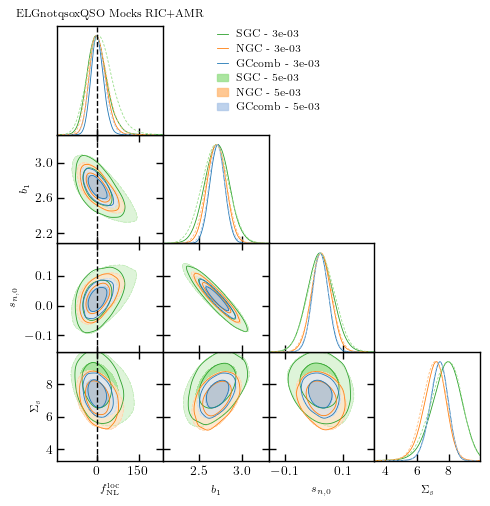

In [20]:
from desilike.samples import Chain

# import getdist.chains
# getdist.chains.print_load_details = False

burnin, thin = 0.3, 10

for tracer in tracer_to_load:

    tracer_save = tracer
    tracer = 'x'.join([tracer[:3], tracer[:3]]) if 'x' not in tracer else tracer.replace('notqso', '')

    for key in ['', 'RIC', 'RIC+AMR']:
        kmin_to_test = [[1e-3, 3e-3], [3e-3, 5e-3], [8e-3, 1e-2]]
        for ii, kmins in enumerate(kmin_to_test):
            try:
                to_display = []
                for kmin in kmins:
                    for region in ['SGC', 'NGC', 'GCcomb']:
                        to_display += [Chain.concatenate([cc.remove_burnin(burnin)[::thin] for cc in chains[(tracer, region, key, kmin)]])]

                from tools import get_getdist_plotter, plot_triangle
                g = get_getdist_plotter(fig_width_inch=5)

                legend_labels = [f'{region} - {kmin:.0e}' for kmin in kmins for region in ['SGC', 'NGC', 'GCcomb']]
                if 'x' in tracer_save:
                    tt1, tt2 = tracer_save.split('x')
                    tt1, tt2 = tt1[:3], tt2[:3]
                    tmp = 'x'.join([tt1, tt2])
                    params = ['fnl_loc', f'{tt2}_{tmp}_ell0.b1', f'{tt1}_{tmp}_ell0x{tt2}_{tmp}_ell0.sn0', f'{tt2}_{tmp}_ell0.sigmas']
                else:
                    tt = tracer_save[:3]
                    params = ['fnl_loc', f'{tt}_ell0.b1', f'{tt}_ell0.sn0', f'{tt}_ell0.sigmas']

                fig = plot_triangle(to_display,  params, legend_labels=legend_labels, 
                                    xlabels=[r'$f_{\rm NL}^{\rm loc}$', r'$b_1$', r'$s_{n,0}$', r'$\Sigma_{s}$'], 
                                    contour_colors=['#2ca02c', '#ff7f0e', '#1f77b4', '#98df8a', '#ffbb78', '#aec7e8',],
                                    filled=[False, False, False, True, True, True],
                                    contour_ls=['-', '-', '-', '--', '--', '--'],  g=g, return_fig=True)

                axs = fig.get_axes()
                for i in range(4):
                    axs[i].axvline(0, ls='--', c='k', lw=1)
                    if tracer_save == 'LRG':
                        axs[i].set_xlim(-60, 40)
                
                #axs[2].axhline(2.151, ls='--', c='k', lw=1)
                axs[3].set_title(f'{tracer_save} Mocks {key}')
                plt.savefig(f'fig/{tracer_save}_mocks_mcmc_test{key}_{ii}.png', dpi=400)
                plt.show()

            except KeyError:
                continue

In [21]:
for tracer in tracer_to_load:

    tracer_save = tracer
    tracer = 'x'.join([tracer[:3], tracer[:3]]) if 'x' not in tracer else tracer.replace('notqso', '')

    if 'x' in tracer_save:
        tt1, tt2 = tracer_save.split('x')
        tt1, tt2 = tt1[:3], tt2[:3]
        tmp = 'x'.join([tt1, tt2])
        params_to_show = ['fnl_loc', f'{tt2}_{tmp}_ell0.b1']
    else:
        tt = tracer_save[:3]
        params_to_show = ['fnl_loc', f'{tt}_ell0.b1']
        
    quantities = ['argmax', 'mean', 'std', 'interval:1sigma']

    for kmin in [1e-3, 3e-3, 5e-3]:
        try: 
            print(f"Results for {tracer_save=} kmin={kmin:.0e}:")
            for region in ['GCcomb', 'NGC', 'SGC']:
                cc = Chain.concatenate([cc.remove_burnin(burnin)[::thin] for cc in chains[(tracer, region, 'RIC+AMR', kmin)]])
                print(cc.to_stats(params=params_to_show, quantities=quantities, tablefmt="pretty"))
        except KeyError:
            continue
        print("\n")

Results for tracer_save='LRG' kmin=1e-03:
Results for tracer_save='LRG' kmin=3e-03:
+-------------+--------+-------+-------+-----------------+
|             | argmax | mean  |  std  | interval:1sigma |
+-------------+--------+-------+-------+-----------------+
|   fnl_loc   |   0.   |  -2   |  11   |   -7.5/+13.3    |
| LRG_ell0.b1 | 2.146  | 2.149 | 0.032 |  -0.033/+0.029  |
+-------------+--------+-------+-------+-----------------+
+-------------+--------+-------+-------+-----------------+
|             | argmax | mean  |  std  | interval:1sigma |
+-------------+--------+-------+-------+-----------------+
|   fnl_loc   |   1    |  -4   |  12   |   -9.6/+14.8    |
| LRG_ell0.b1 | 2.142  | 2.150 | 0.038 |  -0.037/+0.038  |
+-------------+--------+-------+-------+-----------------+
+-------------+--------+-------+-------+-----------------+
|             | argmax | mean  |  std  | interval:1sigma |
+-------------+--------+-------+-------+-----------------+
|   fnl_loc   |   7    |  -5   

In [22]:
import numpy as np
from scipy import stats

def tension_asymmetric(mean, sigma_down, sigma_up, fiducial):
    delta = mean - fiducial

    if delta == 0:
        return 0.0, 1.0, "none (mean == fiducial)"

    if delta > 0:          # fiducial is below the mean
        sigma_eff = sigma_down
        side = "lower (sigma_down used)"
    else:                  # fiducial is above the mean
        sigma_eff = sigma_up
        side = "upper (sigma_up used)"

    tension  = delta / sigma_eff
    p_value  = 2 * stats.norm.sf(abs(tension))
    return tension, float(p_value) #, side

for tracer in tracer_to_load:

    tracer_save = tracer
    tracer = 'x'.join([tracer[:3], tracer[:3]]) if 'x' not in tracer else tracer.replace('notqso', '')

    for kmin in [1e-3, 3e-3, 5e-3]:
        print(f"Results for {tracer_save=} kmin={kmin:.0e}:")
        try: 
            for region in ['GCcomb', 'NGC', 'SGC']:
                cc = Chain.concatenate([cc.remove_burnin(burnin)[::thin] for cc in chains[(tracer, region, 'RIC+AMR', kmin)]])
                cc = cc.to_stats(params=['fnl_loc'], quantities=['mean', 'interval:1sigma'], tablefmt="list")[0]
                mean, sigma = cc[0][1], cc[0][2]
                sigma_down, sigma_up = sigma.split('/')
                mean, sigma_down, sigma_up = float(mean), float(sigma_down), float(sigma_up)
                tension, p_value = tension_asymmetric(mean, sigma_down, sigma_up, fiducial=0)
                print(f"{region}: fnl_loc = {mean:.2f} (+{sigma_up:.2f}/-{sigma_down:.2f}), tension = {tension:.2f} sigma, p-value = {p_value:.3f}")
        except KeyError:
            continue
        print("\n")

Results for tracer_save='LRG' kmin=1e-03:
Results for tracer_save='LRG' kmin=3e-03:
GCcomb: fnl_loc = -2.00 (+13.30/--7.50), tension = -0.15 sigma, p-value = 0.880
NGC: fnl_loc = -4.00 (+14.80/--9.60), tension = -0.27 sigma, p-value = 0.787
SGC: fnl_loc = -5.00 (+25.00/--15.00), tension = -0.20 sigma, p-value = 0.841


Results for tracer_save='LRG' kmin=5e-03:
GCcomb: fnl_loc = 1.00 (+15.00/--12.00), tension = -0.08 sigma, p-value = 0.934
NGC: fnl_loc = 1.00 (+19.00/--15.00), tension = -0.07 sigma, p-value = 0.947
SGC: fnl_loc = -7.00 (+29.00/--20.00), tension = -0.24 sigma, p-value = 0.809


Results for tracer_save='QSO' kmin=1e-03:
GCcomb: fnl_loc = -0.90 (+3.80/--3.60), tension = -0.24 sigma, p-value = 0.813
NGC: fnl_loc = -0.80 (+4.40/--4.30), tension = -0.18 sigma, p-value = 0.856
SGC: fnl_loc = -1.30 (+5.40/--5.30), tension = -0.24 sigma, p-value = 0.810


Results for tracer_save='QSO' kmin=3e-03:
GCcomb: fnl_loc = 0.60 (+7.60/--7.30), tension = -0.08 sigma, p-value = 0.934
NGC: 

## Combined Mean mocks:

In [23]:
from tools import build_total_likelihood

orders = [['LRGxLRG', 'QSOxQSO', 'LRGxQSO']]
orders += [['LRGxLRG', 'QSOxQSO', 'LRGxQSO', 'LRGxELG', 'ELGxQSO']]
orders += [['LRGxLRG', 'QSOxQSO', 'ELGxELG', 'LRGxQSO', 'LRGxELG', 'ELGxQSO']]

kmin_tracer = {'LRGxLRG': 5e-3, 'QSOxQSO': 3e-3, 'LRGxQSO': 5e-3, 'LRGxELG': 5e-3, 'ELGxQSO': 5e-3, 'ELGxELG': 8e-3}

key = 'RIC+AMR'
region = 'GCcomb'

for order in orders:
    print(order)
    obs, lik = {}, {}
    pp, mm = {}, {}
    for tt in order:
        kmin = kmin_tracer[tt]
        # Restrict mocks to k>kmin:
        pp[tt] = mean_mocks[tt][region][key].select(k=(kmin, 1))
        ww = window[tt][region][key].at.observable.match(pp[tt])
        mm[tt] = [mock.select(k=(kmin, 1)) for mock in mocks[tt][region]['RIC+AMR']]   # use 1000 EZmocks

        obs[tt], lik[tt] = get_observable_and_likelihood(pp[tt], ww, mm[tt], tt, zeffs[region], engine='camb', fix_fnl=False, nickname=tt) 

    lik['-'.join(order)] = build_total_likelihood(order, pp, obs, mm, zeffs[region], fiducial)

    profilers[('-'.join(order), region, key, kmin)] = run_profiler(lik['-'.join(order)])
    print(profilers[('-'.join(order), region, key, kmin)].profiles.to_stats(tablefmt="pretty"))
    
    # running chains can be long ... 
    key_tag = 'noIC' if key == '' else key
    fn_chain = f"{dir_chains}/chains_{'-'.join(order)}_nmean_{nmean}_{region}_{key_tag}_kmin-{'-'.join([f'{kmin_tracer[tt]:.0e}' for tt in order])}_*.npy"
    if not Path(fn_chain.replace('*', '0')).exists() or force_mcmc:  # avoid re-running if chain already exists
        chains[('-'.join(order), region, key, '-'.join([f'{kmin_tracer[tt]:.0e}' for tt in order]))] = run_mcmc(lik['-'.join(order)], fn_output=fn_chain, max_iterations=40000, check_every=10000).chains
    else:
        from desilike.samples import Chain
        import glob
        chains[('-'.join(order), region, key, '-'.join([f'{kmin_tracer[tt]:.0e}' for tt in order]))] = [Chain.load(fn) for fn in sorted(glob.glob(fn_chain))]
        Chain.load(fn_chain.replace('*', '0'))
    

['LRGxLRG', 'QSOxQSO', 'LRGxQSO']
+---------------------------------------+--------+---------+-------+
| chi2 / (113 - 9) = 9.69 / 104 = 0.09  | varied | bestfit | error |
+---------------------------------------+--------+---------+-------+
|                fnl_loc                |  True  |  -1.8   |  6.7  |
| LRG_LRGxQSO_ell0xQSO_LRGxQSO_ell0.sn0 |  True  | -0.005  | 0.046 |
|        QSO_LRGxQSO_ell0.sigmas        |  True  |   1.4   |  5.5  |
|             QSO_ell0.sn0              |  True  | -0.032  | 0.056 |
|              QSO_ell0.b1              |  True  |  3.114  | 0.052 |
|            QSO_ell0.sigmas            |  True  |  6.07   | 0.41  |
|             LRG_ell0.sn0              |  True  |  0.111  | 0.056 |
|              LRG_ell0.b1              |  True  |  2.129  | 0.029 |
|            LRG_ell0.sigmas            |  True  |  3.89   | 0.40  |
|          LRG_LRGxQSO_ell2.b1          |  True  |   2.5   |       |
|          QSO_LRGxQSO_ell2.b1          |  True  |   1.1   |       |


+---------+------+-----+-----------------+
|         | mean | std | interval:1sigma |
+---------+------+-----+-----------------+
| fnl_loc |  1   | 14  |     -12/+15     |
+---------+------+-----+-----------------+
+---------+------+-----+-----------------+
|         | mean | std | interval:1sigma |
+---------+------+-----+-----------------+
| fnl_loc | 0.6  | 7.6 |    -7.3/+7.6    |
+---------+------+-----+-----------------+
+---------+------+-----+-----------------+
|         | mean | std | interval:1sigma |
+---------+------+-----+-----------------+
| fnl_loc |  15  | 35  |     -39/+29     |
+---------+------+-----+-----------------+
+---------+------+-----+-----------------+
|         | mean | std | interval:1sigma |
+---------+------+-----+-----------------+
| fnl_loc | -2.5 | 6.9 |    -6.3/+7.4    |
+---------+------+-----+-----------------+


/var/folders/vh/lq2m97v91l34jy4xn7vjsr5h0000gn/T/ipykernel_19564/2527821356.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(f'fig/L+Q+LxQ_mocks_mcmc_kmin_3e-3-5e-3.png', dpi=400)
/opt/homebrew/Caskroom/miniconda/base/envs/cosmo3.12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


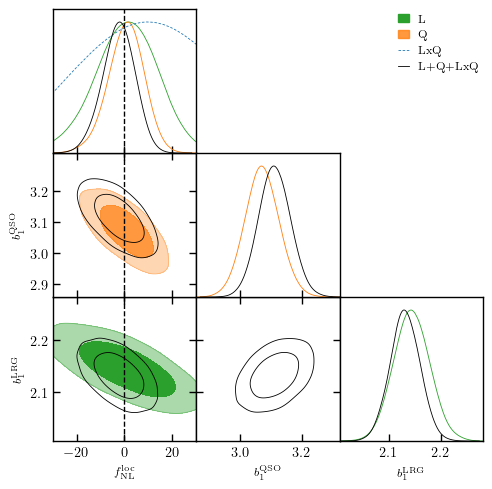

In [24]:
kmin_lrg = 5e-3
kmin_qso = 3e-3
kmin_elgxelg = 8e-3
kmin_lrgxqso = 5e-3
kmin_lrgxelg = 5e-3
kmin_elgxqso = 5e-3


keys = [('LRGxLRG', 'GCcomb', 'RIC+AMR', kmin_lrg), ('QSOxQSO', 'GCcomb', 'RIC+AMR', kmin_qso), ('LRGxQSO', 'GCcomb', 'RIC+AMR', kmin_lrgxqso), ('LRGxLRG-QSOxQSO-LRGxQSO', 'GCcomb', 'RIC+AMR', f'{kmin_lrg:1.0e}-{kmin_qso:1.0e}-{kmin_lrgxqso:1.0e}')]
to_display = [Chain.concatenate([cc.remove_burnin(burnin)[::thin] for cc in chains[key]]) for key in keys]

for cc in to_display:
    print(cc.to_stats(params=['fnl_loc'], quantities=['mean', 'std', 'interval:1sigma'], tablefmt="pretty"))

g = get_getdist_plotter(fig_width_inch=5)

legend_labels = ['L', 'Q', 'LxQ', 'L+Q+LxQ']
params = ['fnl_loc', 'QSO_ell0.b1', 'LRG_ell0.b1']
xlabels = [r'$f_{\rm NL}^{\rm loc}$', r'$b_1^{\rm QSO}$', r'$b_1^{\rm LRG}$']

fig = plot_triangle(to_display,  params, legend_labels=legend_labels, xlabels=xlabels, 
                    contour_colors=['#2ca02c', '#ff7f0e', '#1f77b4', "#000000",],
                    filled=[True, True, False, False],
                    contour_ls=['-', '-', '--', '-'],  g=g, return_fig=True)

axs = fig.get_axes()
for i in range(3): 
    axs[i].axvline(0, ls='--', c='k', lw=1)
    axs[i].set_xlim(-30, 30)

#axs[2].axhline(2.151, ls='--', c='k', lw=1)
plt.savefig(f'fig/L+Q+LxQ_mocks_mcmc_kmin_3e-3-5e-3.png', dpi=400)

plt.show()

+---------+------+-----+-----------------+
|         | mean | std | interval:1sigma |
+---------+------+-----+-----------------+
| fnl_loc |  1   | 14  |     -12/+15     |
+---------+------+-----+-----------------+
+---------+------+-----+-----------------+
|         | mean | std | interval:1sigma |
+---------+------+-----+-----------------+
| fnl_loc | 0.6  | 7.6 |    -7.3/+7.6    |
+---------+------+-----+-----------------+
+---------+------+-----+-----------------+
|         | mean | std | interval:1sigma |
+---------+------+-----+-----------------+
| fnl_loc | -2.5 | 6.9 |    -6.3/+7.4    |
+---------+------+-----+-----------------+
+---------+------+-----+-----------------+
|         | mean | std | interval:1sigma |
+---------+------+-----+-----------------+
| fnl_loc | -3.8 | 7.0 |    -6.8/+7.2    |
+---------+------+-----+-----------------+
+---------+------+-----+-----------------+
|         | mean | std | interval:1sigma |
+---------+------+-----+-----------------+
| fnl_loc |

/var/folders/vh/lq2m97v91l34jy4xn7vjsr5h0000gn/T/ipykernel_19564/1897990556.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(f'fig/L+Q+LxQ+LxE+ExQ_mocks_mcmc_kmin_3e-3-5e-3.png', dpi=400)
/opt/homebrew/Caskroom/miniconda/base/envs/cosmo3.12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


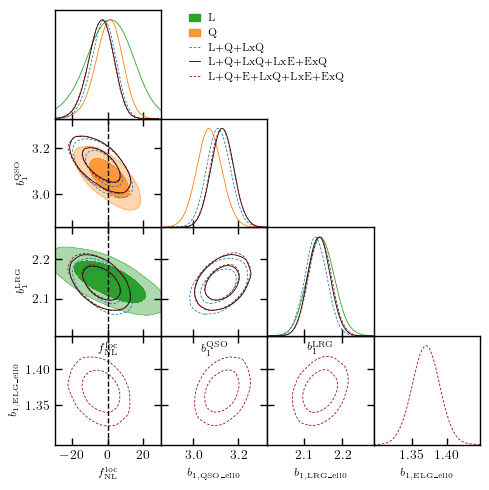

In [25]:
kmin_lrg = 5e-3
kmin_qso = 3e-3
kmin_elgxelg = 8e-3
kmin_lrgxqso = 5e-3
kmin_lrgxelg = 5e-3
kmin_elgxqso = 5e-3

keys = [('LRGxLRG', 'GCcomb', 'RIC+AMR', kmin_lrg), 
        ('QSOxQSO', 'GCcomb', 'RIC+AMR', kmin_qso),
        ('LRGxLRG-QSOxQSO-LRGxQSO', 'GCcomb', 'RIC+AMR', f'{kmin_lrg:1.0e}-{kmin_qso:1.0e}-{kmin_lrgxqso:1.0e}'),
        ('LRGxLRG-QSOxQSO-LRGxQSO-LRGxELG-ELGxQSO', 'GCcomb', 'RIC+AMR', f'{kmin_lrg:1.0e}-{kmin_qso:1.0e}-{kmin_lrgxqso:1.0e}-{kmin_lrgxelg:1.0e}-{kmin_elgxqso:1.0e}'),
        ('LRGxLRG-QSOxQSO-ELGxELG-LRGxQSO-LRGxELG-ELGxQSO', 'GCcomb', 'RIC+AMR', f'{kmin_lrg:1.0e}-{kmin_qso:1.0e}-{kmin_elgxelg:1.0e}-{kmin_lrgxqso:1.0e}-{kmin_lrgxelg:1.0e}-{kmin_elgxqso:1.0e}')
        ]
to_display = [Chain.concatenate([cc.remove_burnin(burnin)[::thin] for cc in chains[key]]) for key in keys]

for cc in to_display:
    print(cc.to_stats(params=['fnl_loc'], quantities=['mean', 'std', 'interval:1sigma'], tablefmt="pretty"))

g = get_getdist_plotter(fig_width_inch=5)

legend_labels = ['L', 'Q', 'L+Q+LxQ', 'L+Q+LxQ+LxE+ExQ', 'L+Q+E+LxQ+LxE+ExQ']
params = ['fnl_loc', 'QSO_ell0.b1', 'LRG_ell0.b1', 'ELG_ell0.b1']
xlabels = [r'$f_{\rm NL}^{\rm loc}$', r'$b_1^{\rm QSO}$', r'$b_1^{\rm LRG}$']

fig = plot_triangle(to_display,  params, legend_labels=legend_labels, xlabels=xlabels, 
                    contour_colors=['#2ca02c', '#ff7f0e', '#1f77b4', "#000000", "#9E1010"],
                    filled=[True, True, False, False, False],
                    contour_ls=['-', '-', '--', '-', '--'],  g=g, return_fig=True)

axs = fig.get_axes()
for i in range(3): 
    axs[i].axvline(0, ls='--', c='k', lw=1)
    axs[i].set_xlim(-30, 30)

#axs[2].axhline(2.151, ls='--', c='k', lw=1)
plt.savefig(f'fig/L+Q+LxQ+LxE+ExQ_mocks_mcmc_kmin_3e-3-5e-3.png', dpi=400)

plt.show()

# Fit each individual mocks:

In [26]:
import itertools
import tqdm
from concurrent.futures import ProcessPoolExecutor

from tools import run_profiling_one_mock


def load_all_profiles(mocks_dir):
    """
    Load all profile .npy files from the holi-v3-altmtl/mock* directories
    and organize them in a nested dictionary structure.
    
    Handles filenames with optional suffixes:
    - bestfit_{tracer}_{cov_type}_kmin-{kmin}.npy
    - bestfit_{tracer}_{cov_type}_kmin-{kmin}_{any_suffix}.npy
    
    Returns:
        profiles: dict with structure {tracer: {cov_type: {kmin: {suffix: {imock: array}}}}}
        where suffix is '' (no suffix) or '_something'
    """
    import re
    from pathlib import Path
    from collections import defaultdict

    base_dir = Path(mocks_dir.replace('summary_statistics', 'profiles')) / 'holi-v3-altmtl'
    
    # Initialize nested dictionary
    profiles = defaultdict(lambda: defaultdict(lambda: defaultdict(lambda: defaultdict(dict))))
    
    # Pattern to parse filenames: captures optional suffix starting with underscore
    pattern = r'bestfit_(.+?)_(analytical_cov|mock_cov)_kmin-([0-9e\-\.]+)(_.*)?\.npy'
    
    # Iterate through all mock directories
    mock_dirs = sorted(base_dir.glob('mock*'), key=lambda x: int(x.name.replace('mock', '')))
    
    for mock_dir in mock_dirs:
        if not mock_dir.is_dir():
            continue
        
        imock = int(mock_dir.name.replace('mock', ''))
        
        # Find all .npy files in this mock directory
        for npy_file in sorted(mock_dir.glob('bestfit_*.npy')):
            match = re.match(pattern, npy_file.name)
            if match:
                tracer, cov_type, kmin, suffix = match.groups()
                kmin = float(kmin)
                suffix = suffix if suffix else ''  # Use empty string if no suffix
                
                # Load the file
                profiles[tracer][cov_type][kmin][suffix][imock] = np.load(str(npy_file))
    
    # Convert defaultdict to regular dict for cleaner output
    profiles = {k: {k2: {k3: {k4: dict(v4) for k4, v4 in v3.items()} for k3, v3 in v2.items()} for k2, v2 in v.items()} 
                for k, v in profiles.items()}
    
    return profiles

def summary_profiles(profiles):
    """ Generate a summary DataFrame of the loaded profiles, showing the number of mocks and range of mock 
        indices for each tracer, covariance type, kmin, and suffix.
    """
    import pandas as pd
    summary_data = []
    for tracer in sorted(profiles):
        for cov_type in sorted(profiles[tracer].keys()):
            for kmin in sorted(profiles[tracer][cov_type].keys()):
                for suffix in sorted(profiles[tracer][cov_type][kmin].keys()):
                    n_mocks = len(profiles[tracer][cov_type][kmin][suffix])
                    mock_indices = sorted(profiles[tracer][cov_type][kmin][suffix].keys())
                    summary_data.append({
                        'Tracer': tracer,
                        'Cov_Type': cov_type,
                        'Kmin': f"{kmin:.1e}",
                        'Suffix': suffix if suffix else '(none)',
                        'N_Mocks': n_mocks,
                        'Mock_Range': f"{min(mock_indices)}-{max(mock_indices)}"
                    })

    summary_df = pd.DataFrame(summary_data)

    return summary_df

def diagnostic_plot(profiles, tracers_to_plot, kmin, extra_fn, nmocks, xlim_fnl=None, xlim_fnlerr=None, fn_fig=None):
    from scipy.stats import norm, chi2

    labels = {'LRGxLRG': 'L', 'QSOxQSO': 'Q', 'LRGxQSO': 'LxQ', 'ELGxELG': 'E', 'LRGxELG': 'LxE', 'ELGxQSO': 'ExQ',
              'LRGxLRG-LRGxQSO-QSOxQSO': 'L+Q+LxQ', 
              'LRGxLRG-LRGxQSO-QSOxQSO-ELGxQSO-LRGxELG-ELGxELG': 'L+Q+E+LxQ+LxE+ExQ'}

    plt.figure(figsize=(10, 3))
    plt.subplot(131)
    if xlim_fnl: plt.xlim(-xlim_fnl, xlim_fnl)
    for tracer in tracers_to_plot:
        prof = profiles[tracer]
        plt.hist([float(prof['mock_cov'][kmin][extra_fn][i][0][2]) for i in range(nmocks)], histtype='step', bins=20, density=True, label=labels[tracer])
        xmin, xmax = plt.xlim()
        x = np.linspace(xmin, xmax, 1000)
        mu, std = norm.fit([float(prof['mock_cov'][kmin][extra_fn][i][0][2]) for i in range(nmocks)])
        plt.plot(x, norm.pdf(x, mu, std), c='k', ls='--', label=f'{mu:2.2f} - {std:2.2f}', zorder=0)
    plt.axvline(0, ls=':', c='gray', alpha=1, zorder=0)
    plt.legend(loc='upper right', ncol=1)
    plt.xlabel('bestfit')

    plt.subplot(132)
    if xlim_fnlerr: plt.xlim(0, xlim_fnlerr)
    for tracer in tracers_to_plot:
        prof = profiles[tracer]
        plt.hist([float(prof['mock_cov'][kmin][extra_fn][i][0][3]) for i in range(nmocks)], histtype='step', bins=20, density=True, label=labels[tracer])
        xmin, xmax = plt.xlim()
        x = np.linspace(xmin, xmax, 1000)
        mu, std = norm.fit([float(prof['mock_cov'][kmin][extra_fn][i][0][3]) for i in range(nmocks)])
        plt.plot(x, norm.pdf(x, mu, std), c='k', ls='--', label=f'{mu:2.2f}', zorder=0)
    plt.legend(loc='upper right', ncol=1)
    plt.xlabel('error')

    plt.subplot(133)
    ndofs = []
    for tracer in tracers_to_plot:
        prof = profiles[tracer]
        idx_logpost = np.where(prof['mock_cov'][kmin][extra_fn][0][:,0] == 'logposterior')[0][0]
        nparams = float(np.sum(prof['mock_cov'][kmin][extra_fn][0][:,3] > ''))
        if "-" not in tracer:  
            nbins = mocks[tracer][0].select(k=(kmin, 1)).size    
        else:
            nbins = sum([mocks[tt][0].select(k=(kmin, 1)).size for tt in tracer.split("-")])
        ndof = nbins - nparams
        ndofs.append(ndof)

        from lsstypes.utils import get_percival2014_factor
        percival = get_percival2014_factor(len(mocks['LRGxLRG']), nbins, nparams)

        red_chi2 = [-2*float(prof['mock_cov'][kmin][extra_fn][i][idx_logpost][2]) * percival / ndof for i in range(nmocks)]

        plt.hist(red_chi2, histtype='step', bins=20, density=True, label=labels[tracer] + f' ({np.mean(red_chi2):.2f})')

    for ndof in np.unique(ndofs):
        x = np.linspace(0.4, 2.0, 500)
        plt.plot(x, chi2.pdf(x, df=ndof, scale=1/ndof), label=fr'$\nu={ndof}$', ls='--', c='k', zorder=0)
    plt.legend()    
    plt.xlabel(r'$\chi^2_{\rm{red}}$')

    plt.tight_layout()
    if fn_fig: plt.savefig(fn_fig, dpi=400)
    plt.show()

In [27]:
## CURRENT STORE PROFILE:

# Load all the available profiles into a nested dictionary for easy access:
profiles = load_all_profiles(mocks_dir)

summary_df = summary_profiles(profiles)
display(summary_df)

,Tracer,Cov_Type,Kmin,Suffix,N_Mocks,Mock_Range
0,ELGxELG,mock_cov,5.0e-03,_RIC+AMR,50,0-49
1,ELGxQSO,mock_cov,5.0e-03,_RIC+AMR,50,0-49
2,LRGxELG,mock_cov,5.0e-03,_RIC+AMR,50,0-49
3,LRGxLRG,mock_cov,3.0e-03,_RIC+AMR,200,0-199
4,LRGxLRG,mock_cov,5.0e-03,_RIC+AMR,200,0-199
5,LRGxLRG-LRGxQSO-QSOxQSO,mock_cov,3.0e-03,_RIC+AMR,200,0-199
6,LRGxLRG-LRGxQSO-QSOxQSO,mock_cov,5.0e-03,_RIC+AMR,200,0-199
7,LRGxQSO,mock_cov,3.0e-03,_RIC+AMR,200,0-199
8,LRGxQSO,mock_cov,5.0e-03,_RIC+AMR,200,0-199
9,QSOxQSO,mock_cov,1.0e-03,_RIC+AMR,200,0-199


In [ ]:
fiducial = propose_fiducial(kmin=1e-3, region='GCcomb')

tracers_to_read = ['LRG', 'QSO', 'LRGxQSO', 'ELGnotqso', 'LRGxELGnotqso', 'ELGnotqsoxQSO']

non_fiducial_binning = False  # test for hartlap factor ... 

window_extra = 'RIC+AMR'
extra_fn = '_' + window_extra if window_extra else ''

if non_fiducial_binning:
    kpivot=[1e-2]
    nrebin=[2]
    extra_fn += '_other_binning'
else:
    kpivot=[1e-2, 2e-2]
    nrebin=[2,2]

pks, windows, covs, zeffs, mocks = {}, {}, {}, {}, {}
alternative_mocks = {}
for tt in tracers_to_read:
    tmp = 'x'.join([tt[:3], tt[:3]]) if 'x' not in tt else tt.replace('notqso', '')
    print(f"Loading data for {tt} ({tmp}) with extra_fn={extra_fn}...")
    pks[tmp], windows[tmp], covs[tmp], zeffs[tmp], mocks[tmp] = load_data(data_dir, mocks_dir, tt, fiducial, window_extra=window_extra,
                                                                          kpivot=kpivot, nrebin=nrebin)
    
    if 'ELG' in tt:
        weight_type_mocks = {'ELGnotqso': 'default-fkp-oqe-wsys-imlin',
                             'LRGxELGnotqso': 'default-fkp-oqexdefault-fkp-oqe-wsys-imlin',
                             'ELGnotqsoxQSO': 'default-fkp-oqe-wsys-imlinxdefault-fkp-oqe'}[tt]
        
        alternative_mocks[tmp] = load_data(data_dir, mocks_dir, tt, fiducial, window_extra=window_extra, weight_type_mocks=weight_type_mocks,
                                           kpivot=kpivot, nrebin=nrebin, nmocks=50)[-1]
        
    else: 
        alternative_mocks[tmp] = None

Loading data for LRG (LRGxLRG) with extra_fn=_RIC+AMR...
Loading data for QSO (QSOxQSO) with extra_fn=_RIC+AMR...
Loading data for LRGxQSO (LRGxQSO) with extra_fn=_RIC+AMR...
Loading data for ELGnotqso (ELGxELG) with extra_fn=_RIC+AMR...
Loading data for LRGxELGnotqso (LRGxELG) with extra_fn=_RIC+AMR...
Loading data for ELGnotqsoxQSO (ELGxQSO) with extra_fn=_RIC+AMR...


In [35]:
#tracers = ['LRGxLRG', 'QSOxQSO', 'LRGxQSO']
tracers = ['ELGxELG', 'LRGxELG', 'ELGxQSO']
#tracers = ['LRGxLRG-LRGxQSO-QSOxQSO'] 
#tracers = ['LRGxLRG-LRGxQSO-QSOxQSO-ELGxQSO-LRGxELG-ELGxELG'] 

analytical_covariances = [False, True][:1]
kmin = [1e-3, 3e-3, 5e-3][1:2]

nmocks = 50

# Do you want to rerun the profiling even if the output file already exists?
force_profiling = False

# Build argument lists for all (tracer, analytical_covariance, imock) combinations:
jobs = list(itertools.product(tracers, range(nmocks), kmin, analytical_covariances))
print(len(jobs), 'jobs to run')

base_dir = mocks_dir.replace('summary_statistics', 'profiles') + f"/holi-v3-altmtl/"

with ProcessPoolExecutor(4) as executor:
    list(tqdm.tqdm(
        executor.map(run_profiling_one_mock,
                    [mocks] * len(jobs),
                    [windows] * len(jobs),
                    [covs] * len(jobs),
                    [t       for t, _, _, _ in jobs],
                    [i       for _, i, _, _ in jobs],
                    [alternative_mocks] * len(jobs),
                    [kk      for _, _, kk, _ in jobs],
                    [ac      for _, _, _, ac in jobs],
                    [force_profiling] * len(jobs),
                    [base_dir] * len(jobs),
                    [fiducial] * len(jobs), 
                    [extra_fn] * len(jobs)),
        total=len(jobs), desc='Profiling mocks'))

# Sequential fallback (npool=1):
# for t, i, kk, ac in jobs:
#     profiler = run_profiling_one_mock(mocks, windows, covs, t, imock=i, alternative_mocks=alternative_mocks,
#                            kmin=kk, analytical_covariance=ac, force_profiling=force_profiling,
#                            base_dir=base_dir, fiducial=fiducial, extra_fn=extra_fn, return_profiler=True)
#     print(profiler.profiles.to_stats(tablefmt="pretty"))

150 jobs to run


Profiling mocks: 100%|██████████| 150/150 [07:10<00:00,  2.87s/it]


In [36]:
# Load all the available profiles into a nested dictionary for easy access:
profiles = load_all_profiles(mocks_dir)

summary_df = summary_profiles(profiles)
display(summary_df)

,Tracer,Cov_Type,Kmin,Suffix,N_Mocks,Mock_Range
0,ELGxELG,mock_cov,3.0e-03,_RIC+AMR,50,0-49
1,ELGxELG,mock_cov,5.0e-03,_RIC+AMR,50,0-49
2,ELGxQSO,mock_cov,3.0e-03,_RIC+AMR,50,0-49
3,ELGxQSO,mock_cov,5.0e-03,_RIC+AMR,50,0-49
4,LRGxELG,mock_cov,3.0e-03,_RIC+AMR,50,0-49
5,LRGxELG,mock_cov,5.0e-03,_RIC+AMR,50,0-49
6,LRGxLRG,mock_cov,3.0e-03,_RIC+AMR,200,0-199
7,LRGxLRG,mock_cov,5.0e-03,_RIC+AMR,200,0-199
8,LRGxLRG-LRGxQSO-QSOxQSO,mock_cov,3.0e-03,_RIC+AMR,200,0-199
9,LRGxLRG-LRGxQSO-QSOxQSO,mock_cov,5.0e-03,_RIC+AMR,200,0-199


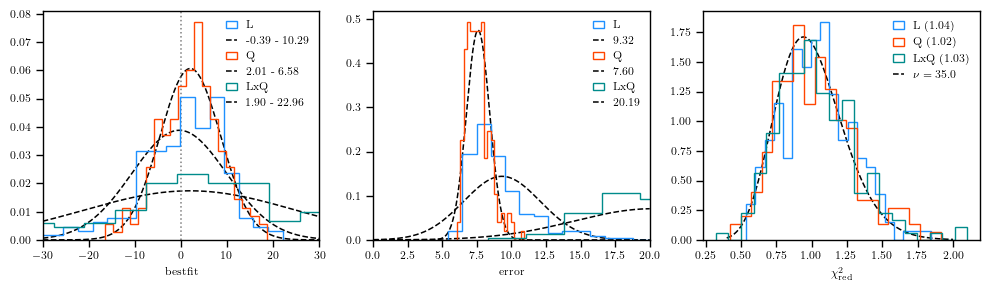

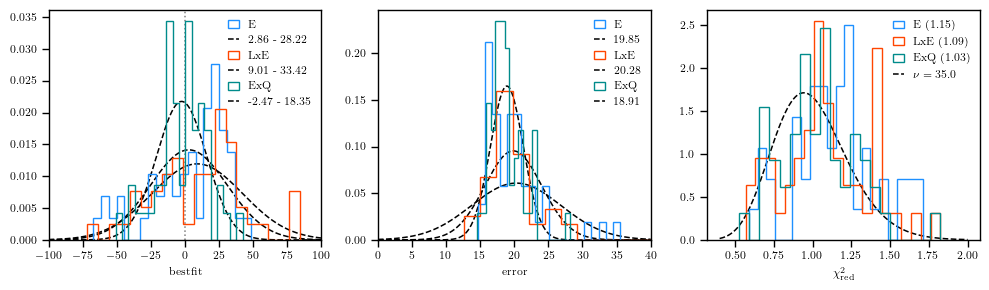

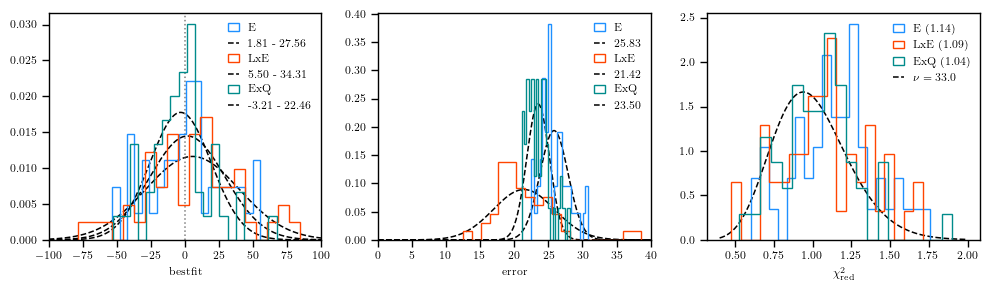

In [37]:
tracers_to_plot = ['LRGxLRG', 'QSOxQSO', 'LRGxQSO'] #, 'LRGxLRG-LRGxQSO-QSOxQSO']
kmin = 3e-3
extra_fn = '_RIC+AMR'
diagnostic_plot(profiles, tracers_to_plot, kmin, extra_fn, 200, xlim_fnl=30, xlim_fnlerr=20, fn_fig='fig/one-by-one_diagnostic_lrg-qso-kmin-{kmin}.png')

tracers_to_plot = ['ELGxELG', 'LRGxELG', 'ELGxQSO']
kmin = 3e-3
extra_fn = '_RIC+AMR'
diagnostic_plot(profiles, tracers_to_plot, kmin, extra_fn, 50, xlim_fnl=100, xlim_fnlerr=40, fn_fig='fig/one-by-one_diagnostic_elg-kmin-{kmin}.png')

tracers_to_plot = ['ELGxELG', 'LRGxELG', 'ELGxQSO']
kmin = 5e-3
extra_fn = '_RIC+AMR'
diagnostic_plot(profiles, tracers_to_plot, kmin, extra_fn, 50, xlim_fnl=100, xlim_fnlerr=40, fn_fig='fig/one-by-one_diagnostic_elg-kmin-{kmin}.png')

In [39]:
tracers_to_plot = ['LRGxLRG-LRGxQSO-QSOxQSO']
kmin = 3e-3
extra_fn = '_RIC+AMR'
#diagnostic_plot(profiles, tracers_to_plot, kmin, extra_fn, 200, xlim_fnl=30, xlim_fnlerr=20)
